# Variable/Constants & Imports

In [61]:
import numpy as np
from iminuit import Minuit
from iminuit.cost import ExtendedBinnedNLL, ExtendedUnbinnedNLL, LeastSquares
from scipy.stats import expon, norm, uniform, chi2
from scipy.integrate import quad
from collections.abc import Callable
import plotly.graph_objects as go
import inspect

n_bins = 57

N = 9874
TAU_MU = 2.1969811e-6
exp_args = {"a": 1, "A": 0, "tau": TAU_MU}

# Functions

In [ ]:

def exp( x , N ,a, A, tau):
    return a*N*expon.cdf(x , A , tau) 

def exp_unif(x, N , min , max , a, tau, A):
    return a * N * (expon.cdf(x, A, tau)*tau/(expon.cdf(max , loc = A , scale = tau) - expon.cdf(min , loc = A , scale = tau)) + (1-a) * N * uniform.cdf(x, min, max))

def double_exp( x , N , a , b , tau1 , tau2 , A ):
    return a * N * (expon.cdf(x, A, tau1)) + b * N * (expon.cdf(x, A, tau2))

def double_exp_unif( x , N , a , b , c , tau1 , tau2 , A , e):
    return a * N * (expon.cdf(x, A, tau1)) + b * N * (expon.cdf(x, A, tau2)) + c * N * (uniform.cdf(x, 0, e))

def exp_unif_pdf( x , a , b , tau , A , e):
    return a * N * (expon.pdf(x, A, tau) + b * N * uniform.pdf(x, 0, e))

def sturges( N: int):
    return int(np.round( 1 + np.log2(N)))

def exp_fit(cdf, a, A, tau, count , edges):
    
    cost = ExtendedBinnedNLL(count, edges, cdf)
    n = Minuit(cost, a, A, tau )
    n.fixed["A"] = True
    n.migrad(ncall = 1000000)
    n.hesse()
    return n

def exp_unif_fit(cdf, a, b, tau, A, count , edges):
    
    cost = ExtendedBinnedNLL(count, edges, cdf)
    n = Minuit(cost, a, b, tau, A )
    # n.fixed['N'] = True
    n.fixed['A'] = True
    # n.limits['b'] = (0, 1)
    n.migrad(ncall = 1000000)
    n.hesse()
    return n

def gauss_fit( cdf , N , mu , sigma , count , edges):
    cost = ExtendedBinnedNLL(count, edges, cdf)
    n = Minuit(cost, N = N , mu = mu , sigma = sigma )
    n.migrad(ncall = 1000000)
    n.hesse()
    return n

def dataset_splitter(data: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    data = data.T
    discriminator = np.array([bool(i) for i in data[1]])


    data_g = data[0][discriminator]
    data_p = data[0][~discriminator]
    return data_g, data_p

#! Funzione per generalizzare la funzione usando la lunghezza del dataset
def function_generator_with_variable_N(func: Callable, N: int) -> Callable:
    sig = inspect.signature(func)
    if "x" not in sig.parameters or "N" not in sig.parameters:
        raise SyntaxError("function defined wrong: it needs an x as first parameter and N as other parameter")
    def wrapper(x, *args, **kwargs):
        return func(x, N, *args, **kwargs)

    wrapper.__signature__ = inspect.Signature(
        [inspect.Parameter('x', inspect.Parameter.POSITIONAL_OR_KEYWORD)] +
        list(inspect.signature(func).parameters.values())[2:]
    )
    return wrapper

def function_generator_with_min_max( func:Callable , dataset:np.ndarray) -> Callable:
    sig = inspect.signature(func)
    if "x" not in sig.parameters or "min" not in sig.parameters or "max" not in sig.parameters:
        raise SyntaxError("function defined wrong: it needs an x as first parameter and N as other parameter")
    def wrapper(x, *args, **kwargs):
        return func(x, min(dataset), max(dataset), *args, **kwargs)

    wrapper.__signature__ = inspect.Signature(
        [inspect.Parameter('x', inspect.Parameter.POSITIONAL_OR_KEYWORD)] +
        list(inspect.signature(func).parameters.values())[3:]
    )
    return wrapper

def dataset_analysis(dataset: np.ndarray , creator: Callable, bins: int , args: dict) -> Minuit:
    model_function = function_generator_with_variable_N( creator , len(dataset))
    sig_params = inspect.signature(model_function).parameters
    if "min" in sig_params and "max" in sig_params:
        model_function = function_generator_with_min_max( model_function , dataset)
    count, edges = np.histogram( dataset , bins=bins) 
    cost = ExtendedBinnedNLL(count, edges, model_function)

    # Snippet to fix a different order between the function definition and args
    sig = str(inspect.signature(model_function))
    sig_list = sig.removeprefix("(").removesuffix(")").split(", ")
    keys = list(args.keys())


    
    if( not all([k in sig_list for k in keys])):
        print( sig_list)
        print(keys) 
        raise KeyError("args is missing a key")
    sig_list.remove("x")
    sorted_args = {k: args[k] for k in sig_list}


    minuit_element =  Minuit(cost, *sorted_args.values())
    
    if "A" in sorted_args.keys():
        minuit_element.fixed["A"] = True

    return minuit_element

def unbinned_data_analysis(dataset: np.ndarray , creator: Callable, args: dict) -> Minuit:
    model_function = function_generator_with_variable_N( creator , len(dataset))
    cost = ExtendedUnbinnedNLL(dataset , model_function)

    # Snippet to fix a different order between the function definition and args
    sig = str(inspect.signature(model_function))
    sig_list = sig.removeprefix("(").removesuffix(")").split(", ")
    keys = list(args.keys())


    
    if( not all([k in sig_list for k in keys])):
        print( sig_list)
        print(keys) 
        raise KeyError("args is missing a key")
    sig_list.remove("x")
    sorted_args = {k: args[k] for k in sig_list}


    minuit_element =  Minuit(cost, *sorted_args.values())
    
    if "A" in sorted_args.keys():
        minuit_element.fixed["A"] = True

    return minuit_element


def end(m:Minuit) -> None:
    m.migrad()
    m.hesse()
    # m.minos()
    display(m)


def find_best_chi2_pvalue( min_bin_range:int , max_bin_range:int , step_bin: int,  f:Callable , dataset:np.ndarray , f_args:dict):
    range_bins = np.arange(min_bin_range , max_bin_range , step_bin , dtype=int)

    p_value_list = []
    chi2_list = []
    for bin in range_bins:
        n = dataset_analysis( dataset , f , bins = bin , args=f_args)
        n.migrad()
        n.hesse()
        p_value_list.append(1 - chi2.cdf(n.fval, df=n.ndof))
        chi2_list.append(n.fval/n.ndof)
    return p_value_list , chi2_list

# Dataset

In [63]:
data_0 = np.genfromtxt("Data/timestamp/21_01_2024_17_42.csv", delimiter=',')
data_1 = np.genfromtxt("Data/timestamp/23_01_2026_17_31.csv", delimiter=',')
data_2 = np.genfromtxt("Data/timestamp/29_01_2026_17_20.csv", delimiter=',')
data_3 = np.genfromtxt("Data/timestamp/02_02_2026_17_14.csv", delimiter=',')
data_4 = np.genfromtxt("Data/timestamp/05_02_2026_18_17.csv", delimiter=',')
data_5 = np.genfromtxt("Data/timestamp/11_02_2026_17_52.csv", delimiter=',')
data_6 = np.genfromtxt("Data/timestamp/16_02_2026_12_25.csv", delimiter=',')
data_7 = np.genfromtxt("Data/timestamp/20_02_2026_15_57.csv", delimiter=',')
inv_data_1 = np.genfromtxt("Data/timestamp/inverted_26_02_2026_16_57.csv" , delimiter=',')
mult_data_1 = np.genfromtxt("Data/timestamp/triple_04_03_2026_05_12.csv",delimiter=",")
mult_data_2 = np.genfromtxt("Data/timestamp/triple_06_03_2026_14_12.csv" , delimiter=",")

data_g_1 , data_p_1 = dataset_splitter( mult_data_1)
data_g_2 , data_p_2 = dataset_splitter( mult_data_2)
print( np.shape(data_g_2) , np.shape(data_g_1))
data_g = np.concatenate((data_g_1, data_g_2))
data_p = np.concatenate( (data_p_1 , data_p_2))




data = np.concatenate((data_0, data_1, data_2, data_3, data_4, data_5, data_6, data_7))

print(len(data),len(data_0), len(data_1), len(data_2), len(data_3), len(data_4), len(data_5), len(data_6), len(data_7) , len(inv_data_1))


(5798,) (1050,)
49799 2976 9400 6139 4577 8759 7456 6355 4137 9874


## Hists

In [64]:

# data_2 = data_2[(data_2 > 0.6e-6) & (data_2 < 1.8e-6)]
inv_data_1_cut = inv_data_1[(inv_data_1 > 3e-7)&(inv_data_1 < 7.6e-6)]
count, edges = np.histogram(data, bins=n_bins , density=False)
count_1, edges_1 = np.histogram(data_1, bins=n_bins , density=False)
count_2, edges_2 = np.histogram(data_2, bins=n_bins , density=False)
count_3, edges_3 = np.histogram(data_3, bins=n_bins , density=False)
count_4, edges_4 = np.histogram(data_4, bins=n_bins , density=False)
count_5, edges_5 = np.histogram(data_5, bins=n_bins , density=False)
count_6, edges_6 = np.histogram(data_6, bins=n_bins , density=False)
count_7, edges_7 = np.histogram(data_7, bins=n_bins , density=False)
count_8, edges_8 = np.histogram(inv_data_1_cut, bins=n_bins , density=False)
print (len(data), len(data_1))
fig = go.Figure()

fig.add_trace(go.Bar(x=edges[:-1],  y=count   / len(data),   name='total',        width=np.diff(edges)))
fig.add_trace(go.Bar(x=edges_1[:-1], y=count_1 / len(data_1), name='23/01/2026',   width=np.diff(edges_1)))
fig.add_trace(go.Bar(x=edges_2[:-1], y=count_2 / len(data_2), name='29/01/2026',   width=np.diff(edges_2)))
fig.add_trace(go.Bar(x=edges_3[:-1], y=count_3 / len(data_3), name='02/02/2026',   width=np.diff(edges_3)))
fig.add_trace(go.Bar(x=edges_4[:-1], y=count_4 / len(data_4), name='05/02/2026',   width=np.diff(edges_4)))
fig.add_trace(go.Bar(x=edges_5[:-1], y=count_5 / len(data_5), name='11/02/2026',   width=np.diff(edges_5)))
fig.add_trace(go.Bar(x=edges_6[:-1], y=count_6 / len(data_6), name='16/02/2026',   width=np.diff(edges_6)))
fig.add_trace(go.Bar(x=edges_7[:-1], y=count_7 / len(data_7), name='20/02/2026',   width=np.diff(edges_7)))
fig.add_trace(go.Bar(x=edges_8[:-1], y=count_8 / len(inv_data_1_cut), name='inverted_26_02_2026_16_57',   width=np.diff(edges_7)))
fig.update_layout(
    xaxis_title='Time (s)',
    yaxis_title='Counts',
    bargap=0
)

fig.show()

49799 9400


# Analysis First set

## Full interpolation 

0.3373549360456939
34804


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.572e+04 (χ²/ndof = 245.7)│             Nfcn = 1667              │
│ EDM = nan (Goal: 0.0002)         │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │  4.17e-1  │    nan    │            │            │         │         │       │
│ 1 │ b    │ 7.7278e-5 │    nan    │            │            │         │         │       │
│ 2 │ tau  │ 1.5837e-4 │    nan    │            │            │         │         │       │
│ 3 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────┐
│     │   a   b tau   A │
├─────┼─────────────────┤
│   a │ nan nan nan   0 │
│   b │ nan nan nan   0 │
│ tau │ nan nan nan   0 │
│   A │   0   0   0   0 │
└─────┴─────────────────┘

/Users/ibolde/.pyenv/versions/3.14.0/lib/python3.14/site-packages/iminuit/minuit.py:2498: IMinuitWarning:

Specified nsigma bound, but error matrix is not accurate

/Users/ibolde/.pyenv/versions/3.14.0/lib/python3.14/site-packages/iminuit/minuit.py:1768: IMinuitWarning:

MIGRAD fails to converge for tau=nan



(array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan]),
 array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan]))

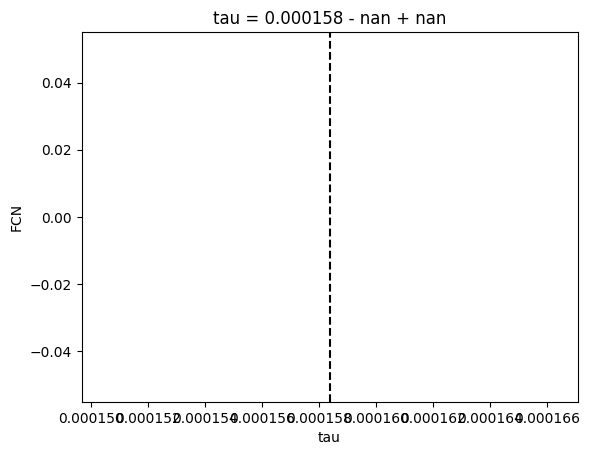

In [ ]:
n_bins = 67
exp_args = {"a": 1, "A": 0, "tau": TAU_MU}

data_refact:np.ndarray = data[(data > 7e-7)&(data < 6.5e-6)]## forse si può anche non tagliare dal basso


n = dataset_analysis( data_refact , exp , bins = n_bins , args=exp_args)

n.migrad()
n.hesse()


p_value = 1 - chi2.cdf(n.fval, df=n.ndof)
print(p_value)

print(len(data_refact))

exp_unif_args = {"a": 0.9, "tau": TAU_MU , "A":0}
g = dataset_analysis( data_refact , exp_unif , bins = n_bins , args=exp_unif_args)
# m.limits["a" , "b"] = (0,1) #type:ignore
# m.fixed["e"] = True
end(g)

g.draw_mnprofile("tau")




In [66]:
print(len(data_2),'\n', 'rate di decadimenti muonici tra il 29genn-2febbr:', 1/(len(data_2)/((24*4)*3600)), 'Hz')
print (len(data_3),'\n', 'rate di decadimenti muonici tra il 2-5 febbraio:', 1/(len(data_3)/((24*3+1)*3600)), 'Hz')
print (len(data_4),'\n', 'rate di decadimenti muonici tra il 5-11 febbraio:', 1/(len(data_4)/((24*4+20)*3600)), 'Hz')

6139 
 rate di decadimenti muonici tra il 29genn-2febbr: 56.29581365043167 Hz
4577 
 rate di decadimenti muonici tra il 2-5 febbraio: 57.4175223945816 Hz
8759 
 rate di decadimenti muonici tra il 5-11 febbraio: 47.67667541956844 Hz


## Plot result + Discrepancy analysis

In [67]:
count,edges = np.histogram(data_refact , n_bins)


fig = go.Figure()
fig.add_trace(go.Bar(x=edges[:-1], y=count/len(data_refact), name='total', width=np.diff(edges)))

x_fit = np.linspace(min(data_refact) , max(data_refact) , n_bins)
y_fit = (g.values["a"]*expon.pdf( x_fit , loc = g.values["A"] , scale = g.values["tau"]) + g.values["b"] * uniform.pdf(x_fit , 0, 8e-6))*np.diff(edges)[0]
y_ideal_fit = (g.values["a"]*expon.pdf( x_fit , loc = g.values["A"] , scale = TAU_MU) + g.values["b"] * uniform.pdf(x_fit , 0, 8e-6))*np.diff(edges)[0]
fig.add_trace(go.Scatter(x=x_fit, y=y_fit, mode='lines', name='fit', line=dict(shape='linear')))
fig.add_trace(go.Scatter(x=x_fit, y=y_ideal_fit, mode='lines', name='ideal fit', line=dict(shape='linear')))

In [68]:
# ho provato a vedere come fossero gli errori poissoniani usando i risultati dell'interpolazione come base

res = (count/len(data_refact)) - y_fit
res_ideal = count/len(data_refact) - y_ideal_fit

fig = go.Figure()
fig.add_trace(go.Scatter(x=x_fit, y=res, mode='markers',  name='residuals'))
fig.add_trace(go.Scatter(x=x_fit, y=res_ideal, mode='markers',  name='ideal residuals'))
fig.add_trace(go.Scatter(x=x_fit, y=res/count * len(data_refact), mode='markers',  name='relative residuals'))
fig.add_trace(go.Scatter(x=x_fit, y=res_ideal/count * len(data_refact), mode='markers',  name='relative ideal residuals'))

fig.show()

In [69]:
min_bin_range = 3
max_bin_range = 200
step_bin = 1
p_value_list , chi2_list = find_best_chi2_pvalue(min_bin_range , max_bin_range ,step_bin , exp , data_refact , exp_args)



In [70]:
fig = go.Figure()

range_bins = np.arange(min_bin_range , max_bin_range , step_bin , dtype=int)

fig.add_trace( go.Scatter( x = range_bins , y = p_value_list , mode="markers" , name="p_value"))
fig.add_trace( go.Scatter( x = range_bins , y = chi2_list , mode="markers" , name="chi squared"))
fig.add_vline(x= sturges(len(data_refact)), line_dash="dash", line_color="purple" , name= "sturges value for binning")
fig.add_hline( y= max(p_value_list) , line_dash="dash", line_color="green" , name= "minimum p_value")
fig.update_layout(showlegend=True)
fig.show()



## Plot  Least Squares

In [71]:
data_refact:np.ndarray = data[(data>1e-7)&(data<7e-6)]

count_LS , edges_LS = np.histogram( data_refact , bins=n_bins)

edges_LS = [ (edges_LS[i+1] + edges_LS[i])/2 for i in range(len(count_LS))]

# fig = go.Figure()
# fig.add_trace( go.Scatter( x = edges_LS , y = count_LS, mode="lines" , name="p_value"))
# fig.show()


ls = LeastSquares( edges_LS , count_LS , np.sqrt(count_LS) , exp_unif_pdf)
exp_unif_args = {"a": 0.9, "b": 0, "tau": TAU_MU , "A":0 , "e": max(data_refact)}
minuit = Minuit( ls , 0.9 , 0 , TAU_MU , 0 , max(data_refact))
minuit.fixed["A"] = True
minuit.migrad()
minuit.hesse()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 61.5 (χ²/ndof = 1.0)       │             Nfcn = 1218              │
│ EDM = 2.46e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │  499e-9   │   6e-9    │            │            │         │         │       │
│ 1 │ b    │  0.01e-3  │  0.07e-3  │            │            │         │         │       │
│ 2 │ tau  │ 2.091e-6  │ 0.033e-6  │            │            │         │         │       │
│ 3 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
│ 4 │ e    │  0.01e-3  │  0.07e-3  │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬───────────────────────────────────────────────────┐
│     │         a         b       tau         A         e │
├─────┼───────────────────────────────────────────────────┤
│   a │  4.16e-17 18.10e-15  0.18e-15         0 31.00e-15 │
│   b │ 18.10e-15  5.07e-09  90.1e-15      0e-9      5e-9 │
│ tau │  0.18e-15  90.1e-15  1.09e-15         0 154.0e-15 │
│   A │         0      0e-9         0         0      0e-9 │
│   e │ 31.00e-15      5e-9 154.0e-15      0e-9  5.24e-09 │
└─────┴───────────────────────────────────────────────────┘

## Double Exponential Interpolation

In [72]:
data_refact:np.ndarray = data[(data>1e-7)&(data<7e-6)]

double_exp_args = {"a": 0.9, "b": 0.2,  "tau1": TAU_MU , "tau2": TAU_MU,  "A":0 }
double = dataset_analysis( data_refact , double_exp , bins = n_bins , args=double_exp_args)
double.limits["a" , "b"] = (0 , 2)
end(double)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 60.95 (χ²/ndof = 1.0)      │              Nfcn = 603              │
│ EDM = 0.000339 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   1.00    │   0.08    │            │            │    0    │    2    │       │
│ 1 │ b    │    0.3    │    0.6    │            │            │    0    │    2    │       │
│ 2 │ tau1 │  2.07e-6  │  0.09e-6  │            │            │         │         │       │
│ 3 │ tau2 │  0.02e-3  │  0.08e-3  │            │            │         │         │       │
│ 4 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────┬──────────────────────────────────────────────────────────────────┐
│      │            a            b         tau1         tau2            A │
├──────┼──────────────────────────────────────────────────────────────────┤
│    a │       0.0061        0.052  7.150217e-9     5.873e-6        0.000 │
│    b │        0.052        0.477 58.475196e-9    52.842e-6          0.0 │
│ tau1 │  7.150217e-9 58.475196e-9     8.84e-15    6.673e-12        0e-15 │
│ tau2 │     5.873e-6    52.842e-6    6.673e-12     5.88e-09         0e-9 │
│    A │        0.000          0.0        0e-15         0e-9            0 │
└──────┴──────────────────────────────────────────────────────────────────┘

# Analysis inversed Dataset

## Single Exponential interpolation

In [ ]:
data_refact = inv_data_1[(inv_data_1 > 3e-7)&(inv_data_1 < 7.6e-6)]

exp_unif_args = {"a": 0.9, "tau": TAU_MU , "A":0}
g = dataset_analysis( data_refact , exp_unif , bins = n_bins , args=exp_unif_args)
end(g)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5384 (χ²/ndof = 84.1)      │              Nfcn = 138              │
│ EDM = nan (Goal: 0.0002)         │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │ 7.5145e-1 │    nan    │            │            │         │         │       │
│ 1 │ b    │ 1.7336e-4 │    nan    │            │            │         │         │       │
│ 2 │ tau  │ 3.8601e-6 │    nan    │            │            │         │         │       │
│ 3 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────┐
│     │   a   b tau   A │
├─────┼─────────────────┤
│   a │ nan nan nan   0 │
│   b │ nan nan nan   0 │
│ tau │ nan nan nan   0 │
│   A │   0   0   0   0 │
└─────┴─────────────────┘

## Double exponential interpolation

In [74]:
data_refact = inv_data_1[(inv_data_1 > 5e-7)&(inv_data_1 < 7.6e-6)]

double_exp_unif_args = {"a": 0.9, "b": 0.2, "c":0.1,  "tau1": TAU_MU , "tau2": TAU_MU,  "A":0 , "e": max(data_refact)}
double = dataset_analysis( data_refact , double_exp_unif , bins = n_bins , args=double_exp_unif_args)
double.fixed["e"] = True
double.limits["a" , "b" , "c"] = (0 , 2)
end(double)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 44.91 (χ²/ndof = 0.7)      │              Nfcn = 868              │
│ EDM = 3.98e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.11    │   0.05    │            │            │    0    │    2    │       │
│ 1 │ b    │   1.24    │   0.06    │            │            │    0    │    2    │       │
│ 2 │ c    │   0.00    │   0.04    │            │            │    0    │    2    │       │
│ 3 │ tau1 │  0.6e-6   │  0.4e-6   │            │            │         │         │       │
│ 4 │ tau2 │  2.42e-6  │  0.11e-6  │            │            │         │         │       │
│ 5 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
│ 6 │ e    │  7.44e-6  │  0.07e-6  │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────┬────────────────────────────────────────────────────────────────────────────────────────────┐
│      │            a            b            c         tau1         tau2            A            e │
├──────┼────────────────────────────────────────────────────────────────────────────────────────────┤
│    a │      0.00301      -0.0029    -0.035e-6  13.24088e-9  5.210909e-9        0.000        0.000 │
│    b │      -0.0029      0.00367           -0 -19.56238e-9 -5.771069e-9        0.000        0.000 │
│    c │    -0.035e-6           -0     3.15e-08    -0.12e-12   -0.141e-12            0            0 │
│ tau1 │  13.24088e-9 -19.56238e-9    -0.12e-12     1.35e-13    0.030e-12            0            0 │
│ tau2 │  5.210909e-9 -5.771069e-9   -0.141e-12    0.030e-12     1.16e-14            0            0 │
│    A │        0.000        0.000            0            0            0            0            0 │
│    e │        0.000        0.000            0            0            0            0            0 │
└──────┴────────────────────────────────────────────────────────────────────────────────────────────┘

In [75]:
data_refact = inv_data_1[(inv_data_1 > 5e-7)&(inv_data_1 < 7.6e-6)]

double_exp_args = {"a": 0.9, "b": 0.2,  "tau1": TAU_MU , "tau2": TAU_MU,  "A":0 }
double = dataset_analysis( data_refact , double_exp , bins = n_bins , args=double_exp_args)
double.limits["a" , "b"] = (0 , 2)
end(double)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 44.91 (χ²/ndof = 0.7)      │              Nfcn = 592              │
│ EDM = 2.69e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.11    │   0.05    │            │            │    0    │    2    │       │
│ 1 │ b    │   1.24    │   0.06    │            │            │    0    │    2    │       │
│ 2 │ tau1 │  0.6e-6   │  0.4e-6   │            │            │         │         │       │
│ 3 │ tau2 │  2.42e-6  │  0.11e-6  │            │            │         │         │       │
│ 4 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────┬──────────────────────────────────────────────────────────────────┐
│      │            a            b         tau1         tau2            A │
├──────┼──────────────────────────────────────────────────────────────────┤
│    a │      0.00302      -0.0029  13.31713e-9  5.233473e-9        0.000 │
│    b │      -0.0029      0.00369 -19.65225e-9 -5.798844e-9        0.000 │
│ tau1 │  13.31713e-9 -19.65225e-9     1.35e-13    0.030e-12            0 │
│ tau2 │  5.233473e-9 -5.798844e-9    0.030e-12     1.16e-14            0 │
│    A │        0.000        0.000            0            0            0 │
└──────┴──────────────────────────────────────────────────────────────────┘

# Analysis multichannel dataset

In [ ]:
data_g_refact = data_g[data_g>5e-7]
data_p_refact = data_p[data_p>5e-7]
print(len(data_g) , len(data_p))
exp_unif_args = {"a": 0.9, "tau": TAU_MU , "A":0}
g = dataset_analysis( data_g_refact , exp_unif , bins = n_bins , args=exp_unif_args)
# m.limits["a" , "b"] = (0,1) #type:ignore
# g.fixed["e"] = True
end(g)

p = dataset_analysis( data_p_refact , exp_unif , bins = n_bins , args=exp_unif_args)
# m.limits["a" , "b"] = (0,1) #type:ignore
# p.fixed["e"] = True
end(p)




complete = np.append( data_g , data_p)
complete_refact = complete[complete>5e-7]


comp = dataset_analysis( complete_refact , exp_unif , bins = n_bins , args=exp_unif_args)
# m.limits["a" , "b"] = (0,1) #type:ignore
# comp.fixed["e"] = True
end(comp)


6848 7806


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2437 (χ²/ndof = 38.1)      │              Nfcn = 88               │
│ EDM = 0.000165 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.90    │   0.21    │            │            │         │         │       │
│ 1 │ b    │  0.26e-3  │  0.06e-3  │            │            │         │         │       │
│ 2 │ tau  │     0     │  0.06e-3  │            │            │         │         │       │
│ 3 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────────────────────────────────┐
│     │          a          b        tau          A │
├─────┼─────────────────────────────────────────────┤
│   a │     0.0441 -12.886e-6    33.9e-9       0.00 │
│   b │ -12.886e-6   3.78e-09         -0       0e-9 │
│ tau │    33.9e-9         -0   3.18e-09          0 │
│   A │       0.00       0e-9          0          0 │
└─────┴─────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3993 (χ²/ndof = 62.4)      │              Nfcn = 192              │
│ EDM = nan (Goal: 0.0002)         │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │ 8.6639e-1 │    nan    │            │            │         │         │       │
│ 1 │ b    │ 1.8488e-4 │    nan    │            │            │         │         │       │
│ 2 │ tau  │ 3.4611e-6 │    nan    │            │            │         │         │       │
│ 3 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────┐
│     │   a   b tau   A │
├─────┼─────────────────┤
│   a │ nan nan nan   0 │
│   b │ nan nan nan   0 │
│ tau │ nan nan nan   0 │
│   A │   0   0   0   0 │
└─────┴─────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6378 (χ²/ndof = 99.7)      │              Nfcn = 97               │
│ EDM = 0.000236 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │    0.9    │    0.7    │            │            │         │         │       │
│ 1 │ b    │  0.11e-3  │  0.09e-3  │            │            │         │         │       │
│ 2 │ tau  │     0     │  0.09e-3  │            │            │         │         │       │
│ 3 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────────────────────────────────┐
│     │          a          b        tau          A │
├─────┼─────────────────────────────────────────────┤
│   a │      0.524 -62.845e-6     169e-9        0.0 │
│   b │ -62.845e-6   7.54e-09      -0e-9       0e-9 │
│ tau │     169e-9      -0e-9   8.01e-09       0e-9 │
│   A │        0.0       0e-9       0e-9          0 │
└─────┴─────────────────────────────────────────────┘

# Hol'up

In [ ]:
print(np.mean(data))
print( np.sqrt(np.var(data)))

print( np.sqrt(np.var(data))/ np.sqrt(len(data)))

2.0450430731540793e-06
1.8650462750819652e-06
8.357556109012115e-09
